# Advanced SentiWise Analysis Pipeline

This notebook demonstrates the new Super Extractor which processes:
- Aspect-Based Sentiment Analysis (ABSA)
- Intent Detection
- Sarcasm Detection
- Emotion Classification
- Per-Review Topic Extraction
- Toxicity & Hate Speech Detection
- Named Entity Recognition (NER)

In [1]:
from sentiwise.core.senti_data import SentiData
from sentiwise.visualization.plotter import plot_time_series
import json

import warnings
warnings.filterwarnings('ignore')

c:\Users\Swapnil\AppData\Local\Programs\Python\Python310\lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.0.6) or chardet (7.4.0.post1)/charset_normalizer (3.3.0) doesn't match a supported version!
  warnings.warn(
c:\Users\Swapnil\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1. Load the Large Advanced Dataset

In [2]:
data = SentiData(file_path="../data/reviews_dataset_large.csv")
print(f"Loaded {len(data.data)} reviews.")

Loaded 63 reviews.


### 2. Run the Advanced Pipeline

Note: The `extract_advanced()` method uses Ollama (Mistral) to extract the topic, intent, emotion, sarcasm, and ABSA features. Ensure `ollama run mistral` is active.

In [3]:
print("Running Pipeline...")
# We chain the methods together for a clean API
data.analyze_sentiment() \
    .detect_toxicity() \
    .extract_ner() \
    .extract_advanced(model="mistral")

print("Pipeline complete!")

Running Pipeline...


100%|██████████| 2/2 [00:03<00:00,  1.61s/it]



Detecting Toxicity...


100%|██████████| 2/2 [00:01<00:00,  1.75it/s]
Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).



Extracting Named Entities...


100%|██████████| 63/63 [00:02<00:00, 26.81it/s]



Running Super Extractor via Ollama (mistral)... This may take a few minutes for large datasets.


100%|██████████| 63/63 [04:29<00:00,  4.28s/it]

Pipeline complete!


### 3. View Results (Super Extractor)

In [5]:
print("\n--- Sample Processed Data ---")
print(json.dumps(data.head(3), indent=3, default=str))


--- Sample Processed Data ---
[
   {
      "sr_no": 1,
      "id": 14,
      "timestamp": "2025-01-02T23:00:00.000",
      "content": "please make this available in android ios alone is not enough",
      "location": "NY",
      "category": "Software",
      "sentiment": "neutral",
      "is_toxic": false,
      "named_entities": "[]",
      "topic": "availability on android",
      "emotion": "anger",
      "intent": "feature_request",
      "sarcasm": false,
      "absa": "[{'aspect': 'availability', 'sentiment': 'negative'}]"
   },
   {
      "sr_no": 2,
      "id": 54,
      "timestamp": "2025-01-05T16:00:00.000",
      "content": "i demand a refund immediately i am never buying from this brand again honestly",
      "location": "TX",
      "category": "Retail",
      "sentiment": "negative",
      "is_toxic": false,
      "named_entities": "[]",
      "topic": "Refund",
      "emotion": "anger",
      "intent": "complaint",
      "sarcasm": false,
      "absa": "[{'aspect': 'bran

### 4. Toxicity and Sarcasm Alerts

In [6]:
toxic_reviews = data.filter_by("is_toxic", True)
print(f"Found {len(toxic_reviews.data)} toxic reviews.")

sarcastic_reviews = data.filter_by("sarcasm", True)
print(f"Found {len(sarcastic_reviews.data)} sarcastic reviews.")

if sarcastic_reviews.data:
    print("\nExample Sarcastic Review:", sarcastic_reviews.data[0]['content'])

Found 3 toxic reviews.
Found 8 sarcastic reviews.

Example Sarcastic Review: oh great another update that completely breaks my workflow brilliant job guys honestly


### 5. Time-Series Sentiment Tracking

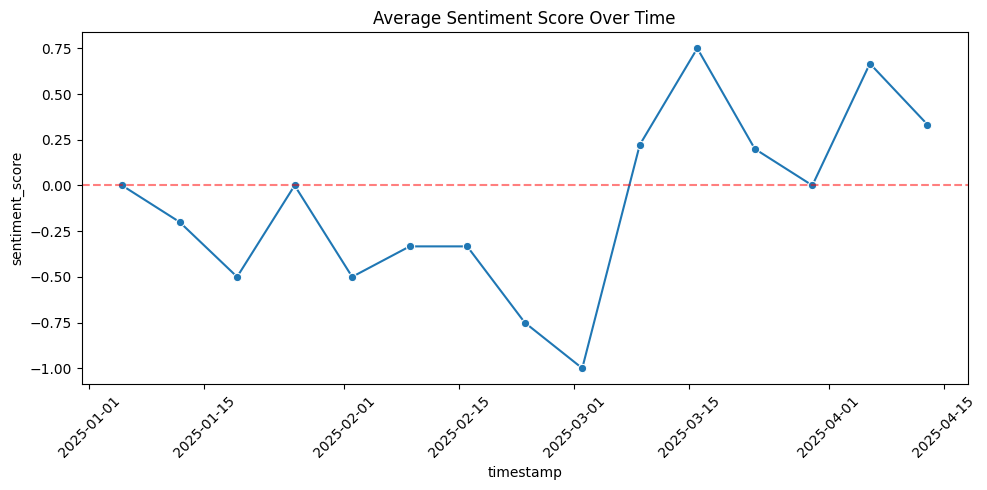

In [7]:
ts_data = data.time_series(freq="W")
plot_time_series(ts_data)

### 6. Topic Modeling & Summarization

Extract distinct topics across all reviews and generate an AI-powered summary for each topic.

In [8]:
data.extract_topics(size=4)
topic_summaries = data.topic_summary(model="mistral")

print("\nTopic-Sentiment Matrix:")
print(data.topic_sentiment())

Batches: 100%|██████████| 2/2 [00:00<00:00, 11.71it/s]



Topic 0
Summary: The review highlights mixed feelings about a specific app, with users praising its speed, clean UI, and impressive battery life, but also criticizing its lack of advanced formatting features, the need for iOS 14 or later to run, and an issue with the battery draining quickly. Additionally, the user mentions they switched from iPhone to Samsung Galaxy and expresses dissatisfaction with Apple's current direction under Tim Cook. The review ends with the user canceling their subscription due to feeling that the app is currently useless.

Topic 1
Summary: The customer demands an immediate refund, expressing dissatisfaction towards the brand for selling a $1000 phone without a charger, stating they will shop elsewhere in future.

Topic 2
Summary: The review indicates frustration over frequent software updates that break workflows, and also mentions a broken zipper on a jacket and positive feedback for quick customer service. The most significant statement is the threat to s

### 7. Data Export

Export the fully enriched dataset (including sentiment, topics, NER, etc.) back to a CSV.

In [9]:
import os
if not os.path.exists("../results"):
    os.makedirs("../results")
data.export("../results/processed_reviews.csv")
print("Data successfully exported to results/processed_reviews.csv")

Data successfully exported to results/processed_reviews.csv
